In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

# from matplotlib.colors import LogNorm
import mpl_scatter_density
from astropy.visualization.mpl_normalize import ImageNormalize

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
sweep_dir = '/Volumes/WD Elements/dr9m-sep26-2020/north/sweep/'
sweep_path_all = np.sort(glob.glob(os.path.join(sweep_dir, '*.fits')))

In [4]:
cat_stack = []
for sweep_path in sweep_path_all:
    cat = Table(fitsio.read(sweep_path, columns=['RA', 'DEC', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'NOBS_W1', 'MASKBITS']))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G'])
        cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R'])
        cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z'])
        mask = (cat['gmag']-cat['rmag']<-4.) & (cat['rmag']-cat['zmag']>4.)
    if np.sum(mask)>0:
        print(np.sum(mask), sweep_path)
        cat_stack.append(cat[mask])

In [5]:
cat = vstack(cat_stack)
print(len(cat))

ValueError: no values provided to stack.

In [85]:
min_nobs = 2
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

91012


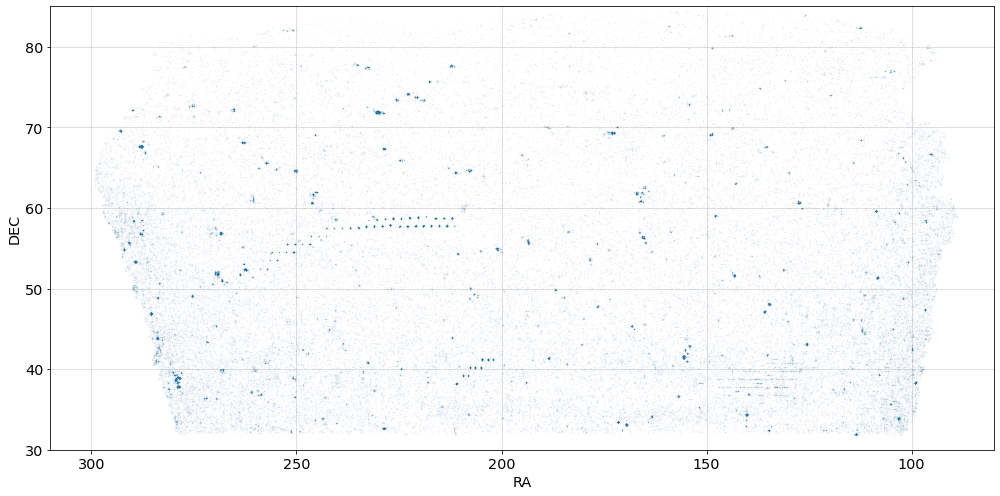

In [86]:
plt.figure(figsize=(14, 7))
plt.plot(cat['RA'], cat['DEC'], '.', color='C0', ms=0.5, alpha=0.1)
plt.axis([310, 80, 30, 85])
plt.grid(alpha=0.5)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.tight_layout()
plt.show()

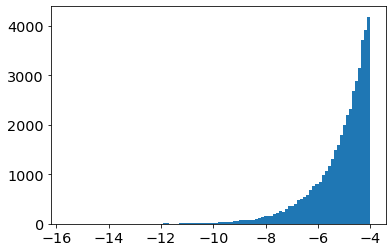

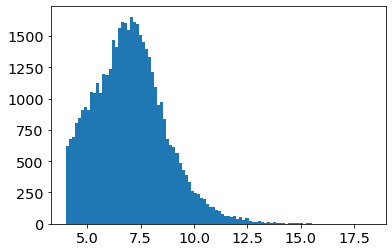

In [87]:
v = cat['gmag']-cat['rmag']
plt.hist(v[np.isfinite(v)], 100)
plt.show()

v = cat['rmag']-cat['zmag']
plt.hist(v[np.isfinite(v)], 100)
plt.show()

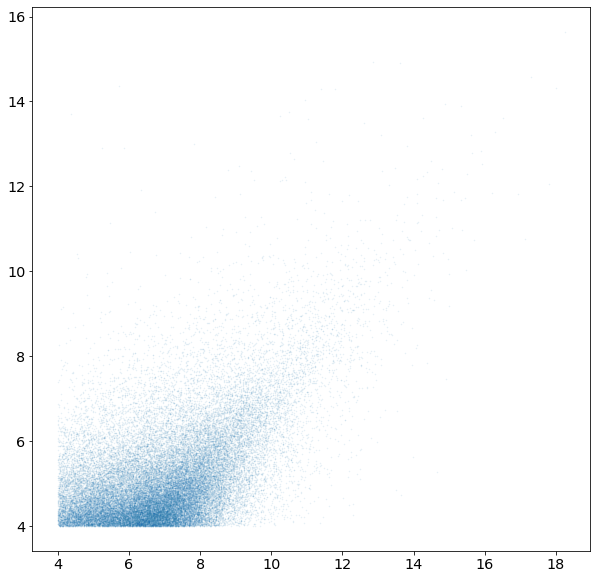

In [88]:
x = cat['rmag']-cat['zmag']
y = cat['rmag']-cat['gmag']
mask = np.isfinite(x) & np.isfinite(y)
plt.figure(figsize=(10, 10))
plt.plot(x, y, '.', ms=1, alpha=0.1)
plt.show()

17977


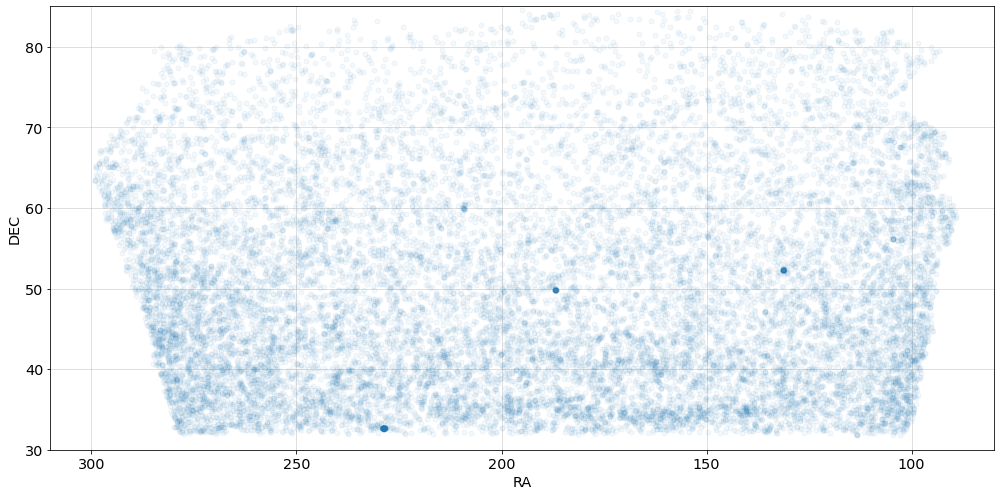

In [89]:
mask = np.isfinite(cat['gmag']) & np.isfinite(cat['rmag']) & np.isfinite(cat['zmag'])
mask &= (cat['gmag']-cat['rmag']<-5.) & (cat['rmag']-cat['zmag']>5.)
np.isfinite(cat['gmag'])
print(np.sum(mask))

plt.figure(figsize=(14, 7))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', color='C0', ms=10, alpha=0.05)
plt.axis([310, 80, 30, 85])
plt.grid(alpha=0.5)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.tight_layout()
plt.show()

91012


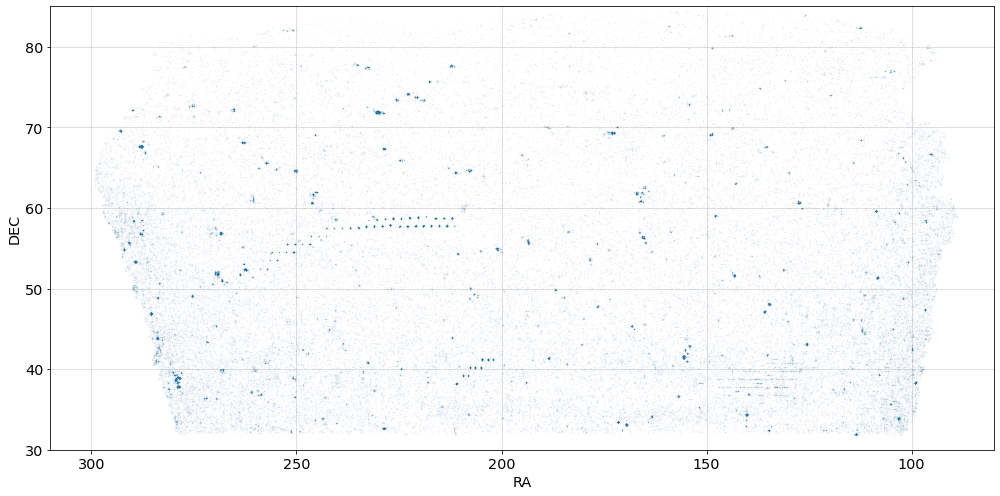

In [90]:
mask = np.isfinite(cat['gmag']) | np.isfinite(cat['rmag']) | np.isfinite(cat['zmag'])
print(np.sum(mask))

plt.figure(figsize=(14, 7))
plt.plot(cat['RA'], cat['DEC'], '.', color='C0', ms=0.5, alpha=0.1)
plt.axis([310, 80, 30, 85])
plt.grid(alpha=0.5)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.tight_layout()
plt.show()

17977


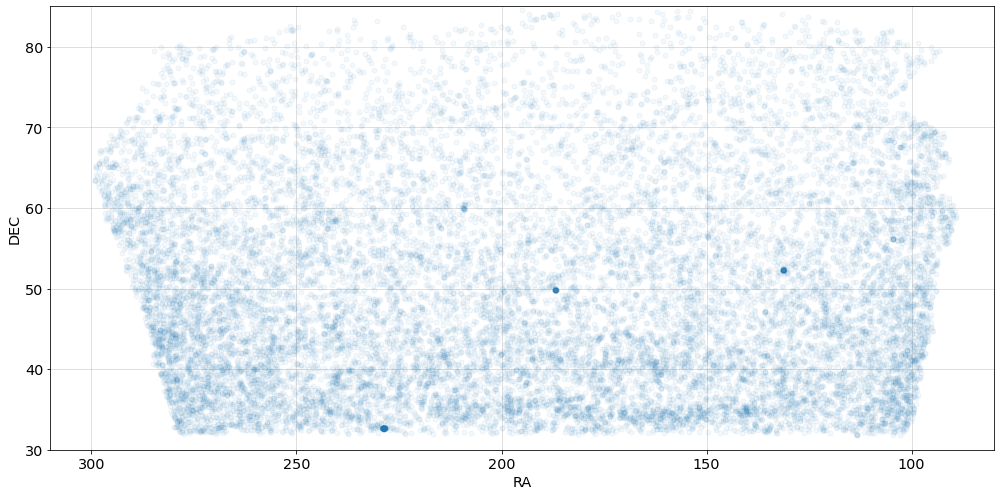

In [89]:
mask = np.isfinite(cat['gmag']) & np.isfinite(cat['rmag']) & np.isfinite(cat['zmag'])
mask &= (cat['gmag']-cat['rmag']<-5.) & (cat['rmag']-cat['zmag']>5.)
np.isfinite(cat['gmag'])
print(np.sum(mask))

plt.figure(figsize=(14, 7))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', color='C0', ms=10, alpha=0.05)
plt.axis([310, 80, 30, 85])
plt.grid(alpha=0.5)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.tight_layout()
plt.show()

-------

In [91]:
mask = np.isfinite(cat['gmag']) | np.isfinite(cat['rmag']) | np.isfinite(cat['zmag'])
print(np.sum(mask))

idx = np.where(mask)[0]
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/Users/rongpu/Downloads/visual_inspection.txt', format='ascii.no_header', overwrite=True)

91012
91012


In [93]:
mask = np.isfinite(cat['gmag']) & np.isfinite(cat['rmag']) & np.isfinite(cat['zmag'])
mask &= (cat['gmag']-cat['rmag']<-5.) & (cat['rmag']-cat['zmag']>5.)
mask &= cat['DEC']>55
np.isfinite(cat['gmag'])
print(np.sum(mask))

idx = np.where(mask)[0]
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/Users/rongpu/Downloads/visual_inspection.txt', format='ascii.no_header', overwrite=True)

5780
5780


In [94]:
mask = np.isfinite(cat['gmag']) & np.isfinite(cat['rmag']) & np.isfinite(cat['zmag'])
mask &= (cat['gmag']-cat['rmag']<-5.) & (cat['rmag']-cat['zmag']>5.)
mask &= cat['DEC']<55
np.isfinite(cat['gmag'])
print(np.sum(mask))

idx = np.where(mask)[0]
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/Users/rongpu/Downloads/visual_inspection1.txt', format='ascii.no_header', overwrite=True)

12197
12197
